In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# Path προς τα January DAM files
folder_path = r"C:\Users\John Kamarinopoulos\Documents\NTUA\ENERGY MARKETS\20.00 PROJECT\January DAM files"
files = glob.glob(os.path.join(folder_path, "*.xlsx"))

os.makedirs("../figures", exist_ok=True)

In [2]:
all_data = []

for file in files:
    df = pd.read_excel(file)

    df = df[
        (df["TARGET"] == "DAM") &
        (df["BIDDING_ZONE_DESCR"] == "Mainland Greece")
    ]

    df = df[["DELIVERY_MTU", "MCP"]]

    all_data.append(df)

merged = pd.concat(all_data)

merged["datetime"] = pd.to_datetime(merged["DELIVERY_MTU"])

merged = merged.groupby("datetime")["MCP"].mean().reset_index()

merged = merged.sort_values("datetime").reset_index(drop=True)

print("Total hours:", len(merged))
print("Mean MCP:", merged["MCP"].mean())

C:\ANACONDA\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\ANACONDA\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\ANACONDA\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\ANACONDA\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\ANACONDA\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook cont

Total hours: 744
Mean MCP: 135.1264582219041


C:\ANACONDA\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [3]:
threshold = merged["MCP"].quantile(0.75)
gas_hours = merged[merged["MCP"] > threshold]

print("Gas-like threshold:", threshold)
print("Gas-like hours:", len(gas_hours))

Gas-like threshold: 151.98499999999999
Gas-like hours: 186


In [4]:
shock_50 = merged.copy()
shock_100 = merged.copy()
shock_130 = merged.copy()

shock_50.loc[shock_50["MCP"] > threshold, "MCP"] *= 1.5
shock_100.loc[shock_100["MCP"] > threshold, "MCP"] *= 2.0
shock_130.loc[shock_130["MCP"] > threshold, "MCP"] *= 2.3

print("Base mean:", merged["MCP"].mean())
print("+50% mean:", shock_50["MCP"].mean())
print("+100% mean:", shock_100["MCP"].mean())
print("+130% mean:", shock_130["MCP"].mean())

Base mean: 135.1264582219041
+50% mean: 158.88367698565938
+100% mean: 182.64089574941465
+130% mean: 196.89522700766778


In [5]:
def count_above_200(df):
    return (df["MCP"] > 200).sum()

print("Base >200€ hours:", count_above_200(merged))
print("+50% >200€ hours:", count_above_200(shock_50))
print("+100% >200€ hours:", count_above_200(shock_100))
print("+130% >200€ hours:", count_above_200(shock_130))

Base >200€ hours: 45
+50% >200€ hours: 186
+100% >200€ hours: 186
+130% >200€ hours: 186


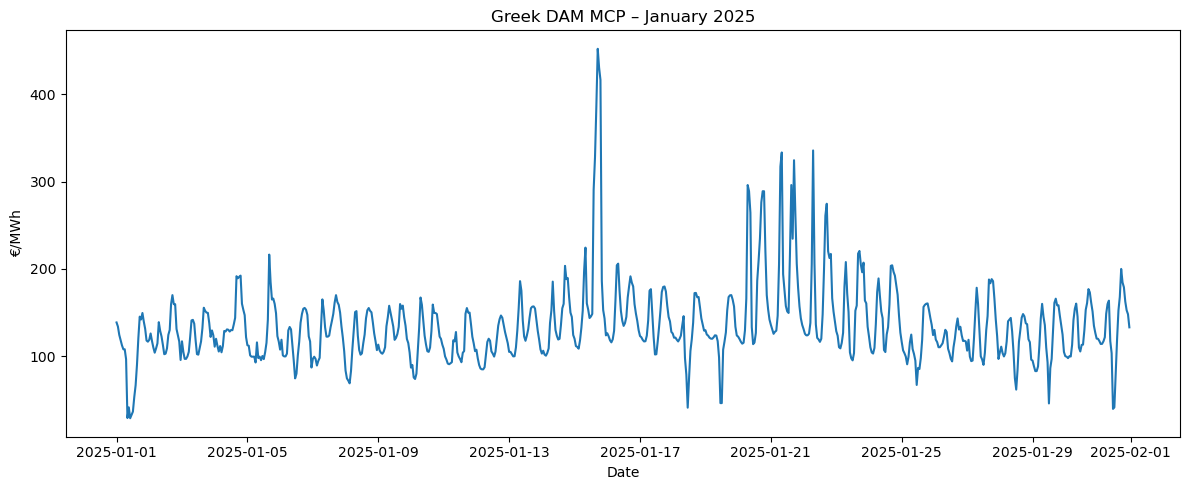

In [6]:
plt.figure(figsize=(12,5))
plt.plot(merged["datetime"], merged["MCP"])
plt.title("Greek DAM MCP – January 2025")
plt.ylabel("€/MWh")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../figures/01_mcp_timeseries.png")
plt.show()

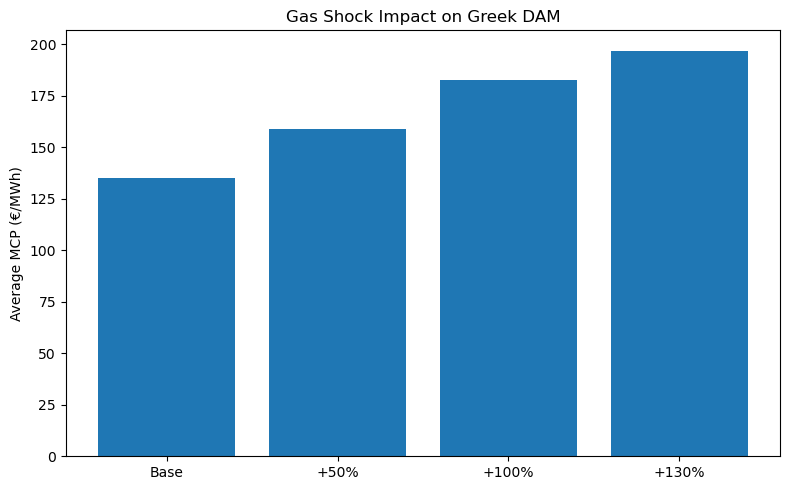

In [7]:
labels = ["Base", "+50%", "+100%", "+130%"]
means = [
    merged["MCP"].mean(),
    shock_50["MCP"].mean(),
    shock_100["MCP"].mean(),
    shock_130["MCP"].mean()
]

plt.figure(figsize=(8,5))
plt.bar(labels, means)
plt.ylabel("Average MCP (€/MWh)")
plt.title("Gas Shock Impact on Greek DAM")
plt.tight_layout()
plt.savefig("../figures/02_average_mcp_scenarios.png")
plt.show()

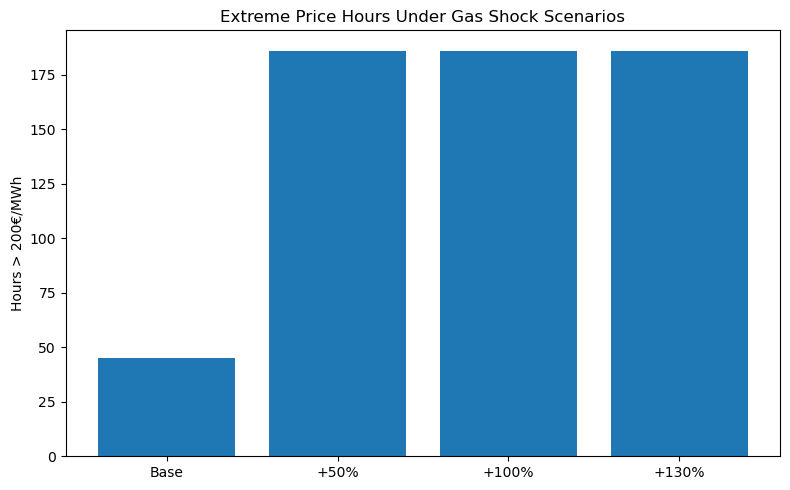

In [8]:
extreme_counts = [
    count_above_200(merged),
    count_above_200(shock_50),
    count_above_200(shock_100),
    count_above_200(shock_130)
]

plt.figure(figsize=(8,5))
plt.bar(labels, extreme_counts)
plt.ylabel("Hours > 200€/MWh")
plt.title("Extreme Price Hours Under Gas Shock Scenarios")
plt.tight_layout()
plt.savefig("../figures/03_extreme_hours.png")
plt.show()

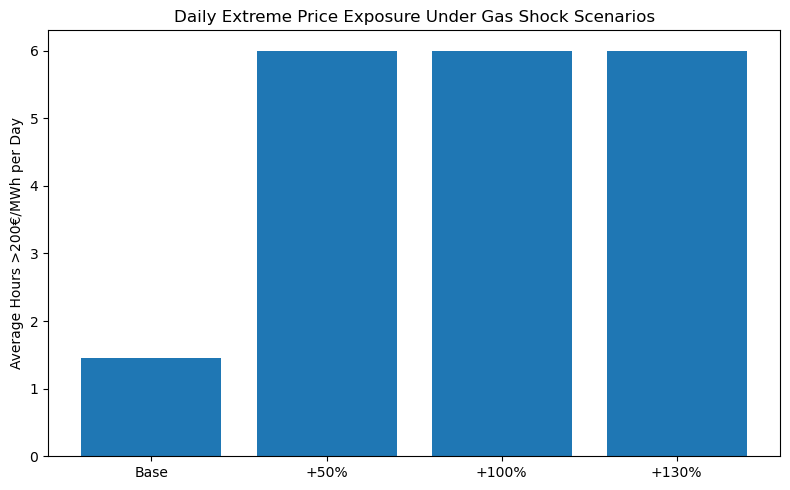

In [9]:
def avg_extreme_hours_per_day(df):
    total_extreme = (df["MCP"] > 200).sum()
    days = df["datetime"].dt.date.nunique()
    return total_extreme / days

avg_extreme = [
    avg_extreme_hours_per_day(merged),
    avg_extreme_hours_per_day(shock_50),
    avg_extreme_hours_per_day(shock_100),
    avg_extreme_hours_per_day(shock_130)
]

labels = ["Base", "+50%", "+100%", "+130%"]

plt.figure(figsize=(8,5))
plt.bar(labels, avg_extreme)
plt.ylabel("Average Hours >200€/MWh per Day")
plt.title("Daily Extreme Price Exposure Under Gas Shock Scenarios")
plt.tight_layout()
plt.savefig("../figures/03_daily_extreme_hours.png")
plt.show()

In [10]:
increase_130 = (shock_130["MCP"].mean() / merged["MCP"].mean() - 1) * 100
print("Extreme scenario increase (%):", increase_130)

Extreme scenario increase (%): 45.711824019191916
